# 🌳 Decision Tree Classification – Heart Disease Dataset
### Complete Step-by-Step Solution
**Dataset:** 908 patients | 13 clinical features | Binary classification (Heart Disease: Yes/No)


---
## Step 1: Data Preparation
Load the dataset and perform initial inspection.


In [1]:
# Import Libaries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)
from sklearn.preprocessing import LabelEncoder


In [2]:
# Load the dataset
df = pd.read_excel('heart_disease.xlsx')# ← update path if needed

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
# Data types and basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.describe()


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


---
## Step 2: Exploratory Data Analysis (EDA)
Understand structure, missing values, distributions, and relationships.


In [6]:
# 2.1 Missing Values 
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0])
print(f"Total missing: {missing.sum()}")


Missing Values per Column:
oldpeak    62
dtype: int64
Total missing: 62


Original 'num' value counts:
num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64
Binarized target (0=No Disease, 1=Disease):
target
1    509
0    399
Name: count, dtype: int64


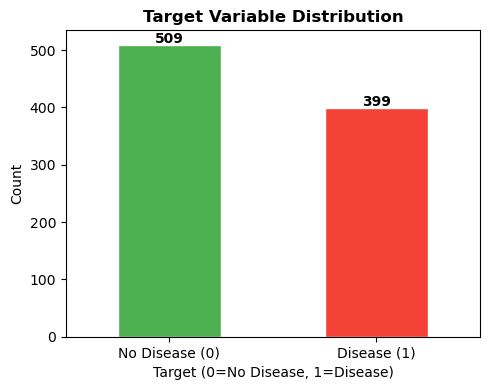

In [7]:
#  2.2 Target Variable Distribution 
print("Original 'num' value counts:")
print(df['num'].value_counts())

# Binarize: 0 = No Disease, 1+ = Disease
df['target'] = (df['num'] > 0).astype(int)

print("Binarized target (0=No Disease, 1=Disease):")
print(df['target'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4CAF50', '#F44336']
df['target'].value_counts().plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_xlabel('Target (0=No Disease, 1=Disease)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height() + 3),
                ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


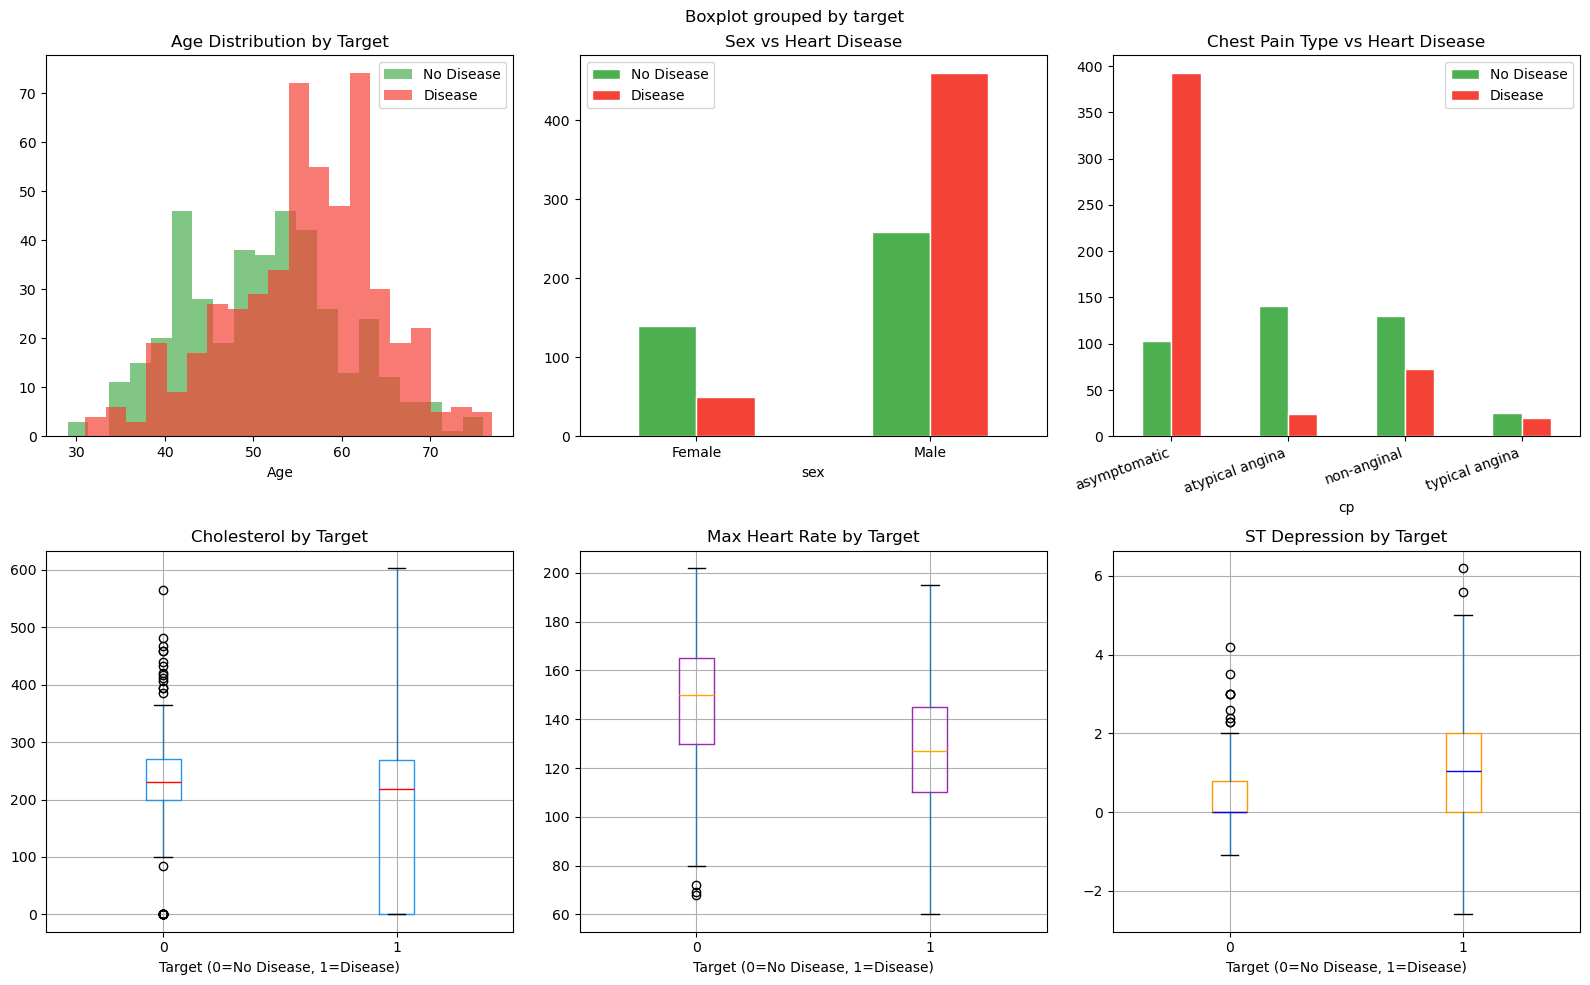

In [8]:
# 2.3 Feature Distributions 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA – Feature Distributions vs Target', fontsize=14, fontweight='bold')

# Age histogram
axes[0,0].hist(df[df['target']==0]['age'], bins=20, alpha=0.7, color='#4CAF50', label='No Disease')
axes[0,0].hist(df[df['target']==1]['age'], bins=20, alpha=0.7, color='#F44336', label='Disease')
axes[0,0].set_title('Age Distribution by Target')
axes[0,0].set_xlabel('Age'); axes[0,0].legend()

# Sex vs Target
sex_target = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_target.plot(kind='bar', ax=axes[0,1], color=['#4CAF50','#F44336'], edgecolor='white')
axes[0,1].set_title('Sex vs Heart Disease')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
axes[0,1].legend(['No Disease', 'Disease'])

# Chest Pain vs Target
cp_target = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_target.plot(kind='bar', ax=axes[0,2], color=['#4CAF50','#F44336'], edgecolor='white')
axes[0,2].set_title('Chest Pain Type vs Heart Disease')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=20, ha='right')
axes[0,2].legend(['No Disease', 'Disease'])

# Cholesterol Boxplot
df.boxplot(column='chol', by='target', ax=axes[1,0],
           boxprops=dict(color='#2196F3'), medianprops=dict(color='red'))
axes[1,0].set_title('Cholesterol by Target')
axes[1,0].set_xlabel('Target (0=No Disease, 1=Disease)')
plt.sca(axes[1,0]); plt.title('Cholesterol by Target')

# Max Heart Rate Boxplot
df.boxplot(column='thalch', by='target', ax=axes[1,1],
           boxprops=dict(color='#9C27B0'), medianprops=dict(color='orange'))
axes[1,1].set_title('Max Heart Rate by Target')
axes[1,1].set_xlabel('Target (0=No Disease, 1=Disease)')
plt.sca(axes[1,1]); plt.title('Max Heart Rate by Target')

# ST Depression Boxplot
df.boxplot(column='oldpeak', by='target', ax=axes[1,2],
           boxprops=dict(color='#FF9800'), medianprops=dict(color='blue'))
axes[1,2].set_title('ST Depression (oldpeak) by Target')
axes[1,2].set_xlabel('Target (0=No Disease, 1=Disease)')
plt.sca(axes[1,2]); plt.title('ST Depression by Target')

plt.tight_layout()
plt.show()


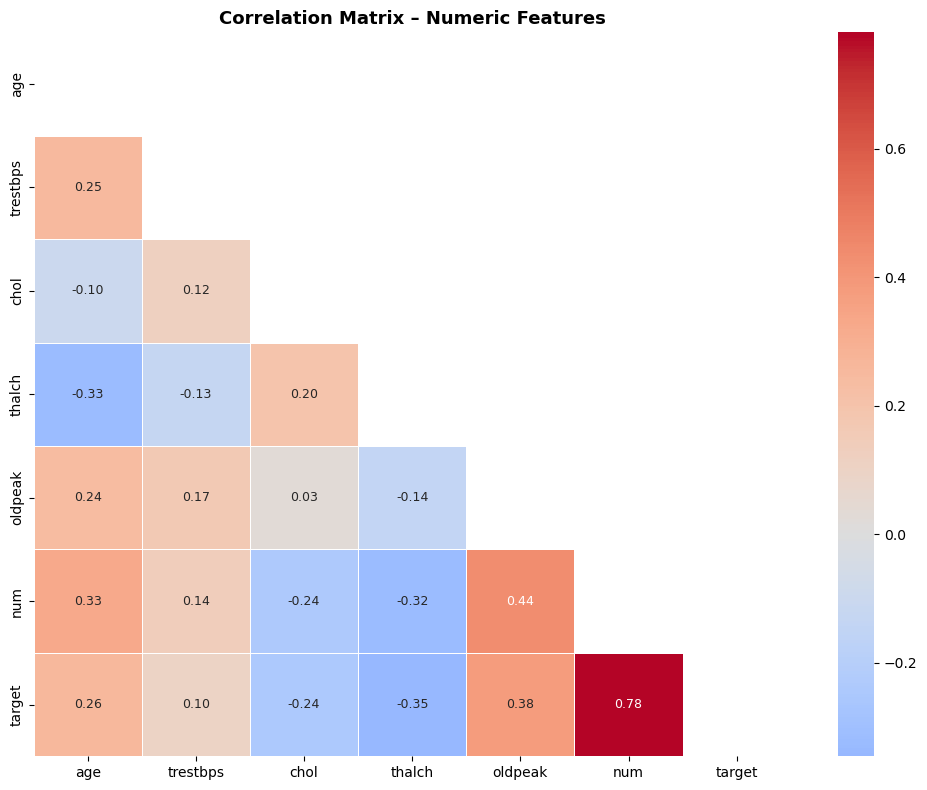


Top correlations with target:
num         0.780881
oldpeak     0.377967
thalch      0.345737
age         0.260603
chol        0.240141
trestbps    0.099337
Name: target, dtype: float64


In [9]:
# 2.4 Correlation Matrix 
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix – Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top correlations with target:")
print(corr['target'].drop('target').abs().sort_values(ascending=False).head(8))


---
## Step 3: Feature Engineering
Handle missing values and encode categorical variables.


In [12]:
# 3.1 Impute Missing Values 
df_enc = df.copy()

print("Missing values before imputation:")
print(df_enc.isnull().sum()[df_enc.isnull().sum() > 0])

# Impute numeric columns with median (robust to outliers)
for col in df_enc.select_dtypes(include=[np.number]).columns:
    if df_enc[col].isnull().sum() > 0:
        median_val = df_enc[col].median()
        df_enc[col].fillna(median_val, inplace=True)
        print(f"  → '{col}' imputed with median = {median_val}")

print("Missing values after imputation:", df_enc.isnull().sum().sum())


Missing values before imputation:
oldpeak    62
dtype: int64
  → 'oldpeak' imputed with median = 0.5
Missing values after imputation: 0


C:\Users\Mitali Patil\AppData\Local\Temp\ipykernel_13788\92683083.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_enc[col].fillna(median_val, inplace=True)


In [13]:
# ── 3.2 Label Encoding for Categorical Columns ───────────────────────────────
cat_cols = df_enc.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}\n")

le = LabelEncoder()
encoding_map = {}

for col in cat_cols:
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    encoding_map[col] = mapping
    print(f"  {col}: {mapping}")

print("Encoding complete!")


Categorical columns to encode: ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal']

  sex: {'Female': 0, 'Male': 1}
  cp: {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
  restecg: {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
  exang: {'FALSE': 0, 'False': 1, 'TURE': 2, 'True': 3}
  slope: {'downsloping': 0, 'flat': 1, 'upsloping': 2}
  thal: {'fixed defect': 0, 'normal': 1, 'reversable defect': 2}
Encoding complete!


In [17]:
# 3.3 Define Features and Target
feature_cols = [c for c in df_enc.columns
                if c not in ['num', 'target'] + cat_cols]

X = df_enc[feature_cols]
y = df_enc['target']

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Target: 'target' (0=No Disease, 1=Disease)")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.head()


Features (12): ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'sex_enc', 'cp_enc', 'restecg_enc', 'exang_enc', 'slope_enc', 'thal_enc']
Target: 'target' (0=No Disease, 1=Disease)
Feature matrix shape: (908, 12)
Target shape: (908,)


,age,trestbps,chol,fbs,thalch,oldpeak,sex_enc,cp_enc,restecg_enc,exang_enc,slope_enc,thal_enc
0,63,145,233,True,150,2.3,1,3,0,1,0,0
1,41,135,203,False,132,0.0,1,1,1,1,1,0
2,57,140,192,False,148,0.4,1,0,1,1,1,0
3,52,118,186,False,190,0.0,1,3,0,1,1,0
4,57,110,201,False,126,1.5,1,0,1,3,1,0


---
## Step 4: Decision Tree Classification
Split data 80/20 and train a baseline Decision Tree model.


In [18]:
#  4.1 Train-Test Split (80-20, Stratified) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTesting  class distribution:\n{y_test.value_counts()}")


Training set size : 726 samples
Testing  set size : 182 samples

Training class distribution:
target
1    407
0    319
Name: count, dtype: int64

Testing  class distribution:
target
1    102
0     80
Name: count, dtype: int64


In [20]:
#  4.2 Baseline Decision Tree 
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
y_prob_base = dt_base.predict_proba(X_test)[:, 1]

print("=" * 50)
print("     BASELINE MODEL PERFORMANCE")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_base):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['No Disease', 'Disease']))


     BASELINE MODEL PERFORMANCE
  Accuracy  : 0.7527
  Precision : 0.7879
  Recall    : 0.7647
  F1-Score  : 0.7761
  ROC-AUC   : 0.7511

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.71      0.74      0.72        80
     Disease       0.79      0.76      0.78       102

    accuracy                           0.75       182
   macro avg       0.75      0.75      0.75       182
weighted avg       0.75      0.75      0.75       182



---
## Step 5: Hyperparameter Tuning
Use GridSearchCV with 5-fold cross-validation to find optimal parameters.


In [21]:
#  5.1 GridSearchCV 
param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

print("Running GridSearchCV (5-fold CV)... this may take ~30 seconds")

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f"\n✅ Search complete!")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")


Running GridSearchCV (5-fold CV)... this may take ~30 seconds

✅ Search complete!
Best Parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1-Score: 0.7861


In [22]:
#  5.2 Tuned Model Evaluation 
dt_tuned = grid_search.best_estimator_
y_pred_tuned = dt_tuned.predict(X_test)
y_prob_tuned = dt_tuned.predict_proba(X_test)[:, 1]

acc_t  = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t  = recall_score(y_test, y_pred_tuned)
f1_t   = f1_score(y_test, y_pred_tuned)
auc_t  = roc_auc_score(y_test, y_prob_tuned)

print("=" * 50)
print("       TUNED MODEL PERFORMANCE")
print("=" * 50)
print(f"  Accuracy  : {acc_t:.4f}")
print(f"  Precision : {prec_t:.4f}")
print(f"  Recall    : {rec_t:.4f}")
print(f"  F1-Score  : {f1_t:.4f}")
print(f"  ROC-AUC   : {auc_t:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))


       TUNED MODEL PERFORMANCE
  Accuracy  : 0.7198
  Precision : 0.7742
  Recall    : 0.7059
  F1-Score  : 0.7385
  ROC-AUC   : 0.7710

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.66      0.74      0.70        80
     Disease       0.77      0.71      0.74       102

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.73      0.72      0.72       182



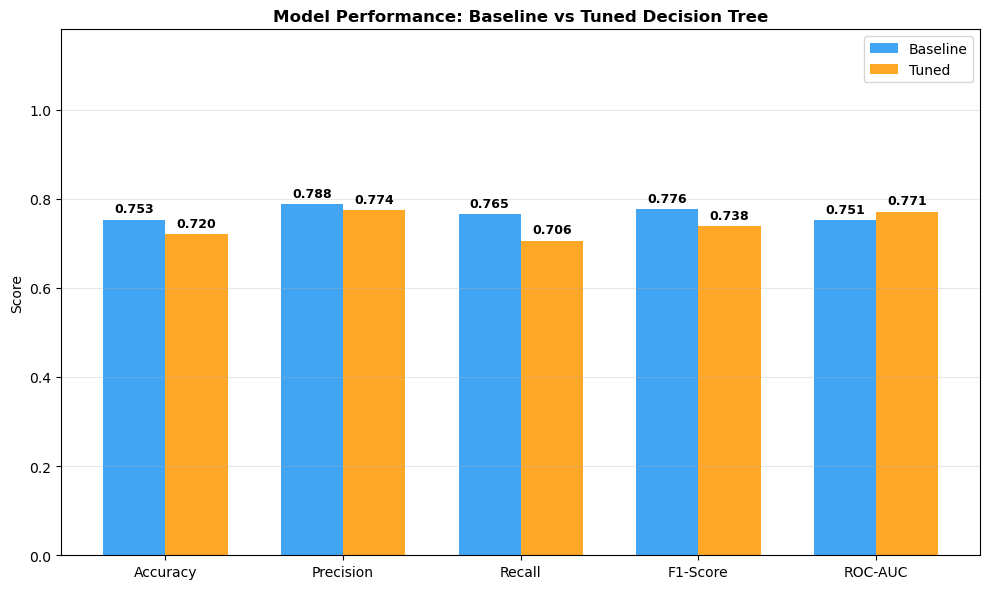


Improvement summary:
  Accuracy    : 0.7527 → 0.7198  ↓ 3.3%
  Precision   : 0.7879 → 0.7742  ↓ 1.4%
  Recall      : 0.7647 → 0.7059  ↓ 5.9%
  F1-Score    : 0.7761 → 0.7385  ↓ 3.8%
  ROC-AUC     : 0.7511 → 0.7710  ↑ 2.0%


In [25]:
#  5.3 Baseline vs Tuned Comparison 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
base_vals  = [accuracy_score(y_test, y_pred_base), precision_score(y_test, y_pred_base),
              recall_score(y_test, y_pred_base), f1_score(y_test, y_pred_base),
              roc_auc_score(y_test, y_prob_base)]
tuned_vals = [acc_t, prec_t, rec_t, f1_t, auc_t]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, base_vals, w, label='Baseline', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, tuned_vals, w, label='Tuned',    color='#FF9800', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Model Performance: Baseline vs Tuned Decision Tree', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nImprovement summary:")
for m, b, t in zip(metrics, base_vals, tuned_vals):
    diff = t - b
    arrow = '↑' if diff > 0 else '↓'
    print(f"  {m:<12}: {b:.4f} → {t:.4f}  {arrow} {abs(diff)*100:.1f}%")


---
## Step 6: Model Evaluation and Analysis
Confusion matrices, ROC curves, feature importances, and tree visualisation.


In [ ]:
#  6.1 Confusion Matrices 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices – Baseline vs Tuned', fontsize=13, fontweight='bold')

for ax, y_pr, title in zip(axes,
                            [y_pred_base, y_pred_tuned],
                            ['Baseline Decision Tree', 'Tuned Decision Tree']):
    cm = confusion_matrix(y_test, y_pr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1.5, linecolor='white', annot_kws={'size': 14})
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')
    
    # Add TN, FP, FN, TP labels
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}:")
    print(f"  True Negatives  (TN): {tn}  |  False Positives (FP): {fp}")
    print(f"  False Negatives (FN): {fn}  |  True Positives  (TP): {tp}")

plt.tight_layout()
plt.show()


In [ ]:
#  6.2 ROC Curves 
fig, ax = plt.subplots(figsize=(7, 6))

for y_pr, label, color, ls in [
        (y_prob_base,  f'Baseline  (AUC = {roc_auc_score(y_test, y_prob_base):.3f})', '#2196F3', '-'),
        (y_prob_tuned, f'Tuned     (AUC = {auc_t:.3f})', '#FF9800', '-')]:
    fpr, tpr, _ = roc_curve(y_test, y_pr)
    ax.plot(fpr, tpr, lw=2.5, color=color, linestyle=ls, label=label)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.fill_between(*roc_curve(y_test, y_prob_tuned)[:2], alpha=0.08, color='#FF9800')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
#  6.3 Feature Importances 
importances = pd.Series(dt_tuned.feature_importances_, index=feature_cols).sort_values()
mean_imp = importances.mean()

bar_colors = ['#009688' if v > mean_imp else '#2196F3' for v in importances.values]

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axvline(mean_imp, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean_imp:.3f}')
ax.set_title('Feature Importances – Tuned Decision Tree', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.legend()
ax.grid(axis='x', alpha=0.3)

for i, (name, val) in enumerate(importances.items()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<18}: {imp:.4f}  ({imp*100:.1f}% importance)")


In [ ]:
#  6.4 Decision Tree Visualisation 
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_tuned,
          feature_names=feature_cols,
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True,
          fontsize=8, proportion=False,
          impurity=True, ax=ax)
ax.set_title('Decision Tree Structure (Tuned – max_depth=4)',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [ ]:
#  6.5 Text Representation of Decision Rules
print("Decision Tree Rules (Tuned Model):")
print("=" * 60)
tree_rules = export_text(dt_tuned, feature_names=feature_cols)
print(tree_rules)


In [ ]:
#  Final Summary 
print("=" * 60)
print("         FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset        : Heart Disease (908 samples, 12 features)")
print(f"  Train/Test     : 80/20 stratified split")
print(f"  Best Model     : Tuned Decision Tree")
print(f"  Best Params    : {grid_search.best_params_}")
print()
print("  Metric         Baseline    Tuned       Δ Change")
print("  " + "-"*52)
metrics_final = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
base_final  = [accuracy_score(y_test,y_pred_base), precision_score(y_test,y_pred_base),
               recall_score(y_test,y_pred_base), f1_score(y_test,y_pred_base),
               roc_auc_score(y_test,y_prob_base)]
tuned_final = [acc_t, prec_t, rec_t, f1_t, auc_t]
for m, b, t in zip(metrics_final, base_final, tuned_final):
    arrow = '↑' if t>b else '↓'
    print(f"  {m:<14} {b:.4f}      {t:.4f}      {arrow}{abs(t-b)*100:.1f}%")
print("=" * 60)
print("Top Feature: Chest Pain Type (cp_enc) — most discriminative!")


---
## Interview Questions

**1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?**

- **`max_depth`** — the maximum number of levels the tree can grow to. A small `max_depth` keeps the tree shallow and simple (higher bias, less likely to overfit but may underfit); a large or unlimited `max_depth` lets the tree keep splitting until nodes are pure, which can memorize noise in the training data (low bias, high variance/overfitting). In this notebook, `GridSearchCV` tested depths of 3, 4, 5, 6, 7, and `None`.
- **`min_samples_split`** — the minimum number of samples a node must have before it's allowed to split further. Higher values prevent the tree from creating splits based on very small, potentially noisy subsets, which reduces overfitting; lower values allow more granular (and potentially overfit) splits.
- **`min_samples_leaf`** — the minimum number of samples required in a leaf node. Increasing it smooths the model by forcing each leaf to represent a reasonably sized group of patients rather than a single outlier, which reduces variance at the cost of some accuracy on the training set.
- **`criterion`** — the impurity measure used to evaluate splits, typically `'gini'` (Gini impurity) or `'entropy'` (information gain). Both usually produce similar trees; Gini is slightly faster to compute, while entropy is a bit more sensitive to changes in class probabilities. This mainly affects *which* splits are chosen, not the overall model complexity.
- **`max_features`** — the number of features considered when looking for the best split. Restricting this can add useful randomness and reduce overfitting, especially in ensembles built from trees (e.g. Random Forests).

In general, the depth-related and sample-count hyperparameters (`max_depth`, `min_samples_split`, `min_samples_leaf`) are the main levers for controlling the classic **bias-variance tradeoff**: shallower/more restricted trees generalize better but may miss real patterns, while deeper/less restricted trees fit the training data closely but risk overfitting and performing worse on unseen data. This is exactly what `GridSearchCV` in Step 5 searches over to find the best-generalizing combination.

**2. What is the difference between Label Encoding and One-Hot Encoding?**

- **Label Encoding** converts each category into a single integer (e.g. `Male → 0`, `Female → 1`, or `cp_typical → 0`, `cp_atypical → 1`, `cp_non-anginal → 2`, `cp_asymptomatic → 3`). It's compact — only one new column per feature — but it implicitly introduces an **ordinal relationship** between categories (implying `3 > 2 > 1 > 0`) even when the categories have no real order. This can mislead models that assume numeric relationships between feature values, but it's generally *fine for tree-based models* like Decision Trees, since a tree just picks split thresholds on the encoded values and doesn't assume any linear or distance-based relationship. This is why `LabelEncoder` was used for the categorical columns in Step 3.2 of this notebook.
- **One-Hot Encoding** creates a separate binary (0/1) column for each category (e.g. `cp_typical`, `cp_atypical`, `cp_non-anginal`, `cp_asymptomatic`, each 0 or 1). This avoids implying any order between categories, which matters for models that rely on distances or linear combinations of features (e.g. Logistic Regression, KNN, SVM, Neural Networks). The tradeoff is higher dimensionality — a categorical feature with many unique values produces many new columns, which can slow training and increase the risk of sparsity/overfitting.

**Rule of thumb:** use Label Encoding for tree-based models (Decision Trees, Random Forests, Gradient Boosting) where ordinality doesn't distort the splits, and use One-Hot Encoding for distance-based or linear models where treating categories as ordered numbers would introduce a false relationship.